# Hybrid Movie Recommendation System — Exploration Notebook

This notebook walks through the full pipeline:
data loading → preprocessing → vectorization → evaluation → example outputs.

---

## 1. Imports

Add the project root to `sys.path` so the `src/` package is importable from the `notebooks/` subdirectory.

In [1]:
import sys
import os

# Make src/ importable and resolve relative data paths from the project root
sys.path.insert(0, '..')
os.chdir('..')   # so 'data/tfidf_cache.pkl' resolves to project root

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from datasets import load_dataset

from src.preprocess import preprocess_dataframe, clean_text
from src.vectorizer import build_tfidf_matrix, save_cache, load_cache, cache_exists
from src.recommender import HybridMovieRecommender

print('All imports successful.')

c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.


---

## 2. Model Loading

Load from the joblib cache if it exists (fast path), otherwise build the full pipeline:
download dataset → preprocess → TF-IDF vectorise → save cache.
Then attach the vectorizer to the recommender so `recommend_by_description` works.

In [2]:
if cache_exists():
    print('Cache found — loading from disk...')
    vectorizer, tfidf_matrix, df = load_cache()
    print(f'  Loaded {len(df):,} movies from cache.')
else:
    print('No cache found — building from scratch (this may take ~60 s)...')

    print('  Downloading dataset...')
    raw_df = load_dataset('jquigl/imdb-genres')['train'].to_pandas()
    print(f'  Raw dataset: {raw_df.shape}')

    print('  Preprocessing...')
    df = preprocess_dataframe(raw_df)
    df = df.dropna(subset=['enriched_text'])
    df = df[df['movie title - year'].notna()]
    df = df.reset_index(drop=True)

    print('  Vectorizing...')
    vectorizer, tfidf_matrix = build_tfidf_matrix(df['enriched_text'].tolist())

    print('  Saving cache...')
    save_cache(vectorizer, tfidf_matrix, df)

recommender = HybridMovieRecommender(df, tfidf_matrix)
recommender.vectorizer = vectorizer

print(f'\nRecommender ready — {len(df):,} movies in index.')

Cache found — loading from disk...
  [cache] Loading from data/tfidf_cache.pkl...
  Loaded 222,605 movies from cache.

Recommender ready — 222,605 movies in index.


---

## 3. Dataset Exploration

Inspect the preprocessed dataframe: shape, column types, missing values,
description length distribution, and the most common genres.

In [3]:
print('=== Shape ===')
print(df.shape)

print('\n=== Columns ===')
print(df.columns.tolist())

print('\n=== Data types ===')
print(df.dtypes)

print('\n=== Null counts ===')
print(df.isnull().sum())

print('\n=== Clean description length (word count) ===')
desc_lengths = df['clean_description'].str.split().str.len()
print(desc_lengths.describe().round(2))

print('\n=== Top 10 genres (expanded-genres column) ===')
genre_series = (
    df['expanded-genres']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)
print(genre_series.value_counts().head(10))

=== Shape ===
(222605, 8)

=== Columns ===
['movie title - year', 'genre', 'expanded-genres', 'rating', 'description', 'clean_description', 'desc_word_count', 'enriched_text']

=== Data types ===
movie title - year     object
genre                  object
expanded-genres        object
rating                float64
description            object
clean_description      object
desc_word_count         int64
enriched_text          object
dtype: object

=== Null counts ===
movie title - year        0
genre                     0
expanded-genres           0
rating                62561
description               0
clean_description         0
desc_word_count           0
enriched_text             0
dtype: int64

=== Clean description length (word count) ===
count    222605.00
mean         17.21
std           4.89
min           8.00
25%          13.00
50%          18.00
75%          21.00
max          49.00
Name: clean_description, dtype: float64

=== Top 10 genres (expanded-genres column) ===
expan

---

## 4. Genre Distribution Chart

Horizontal bar chart of the top 15 genres derived from the `expanded-genres` column.
Each movie can contribute to multiple genre bins since the column is multi-label.

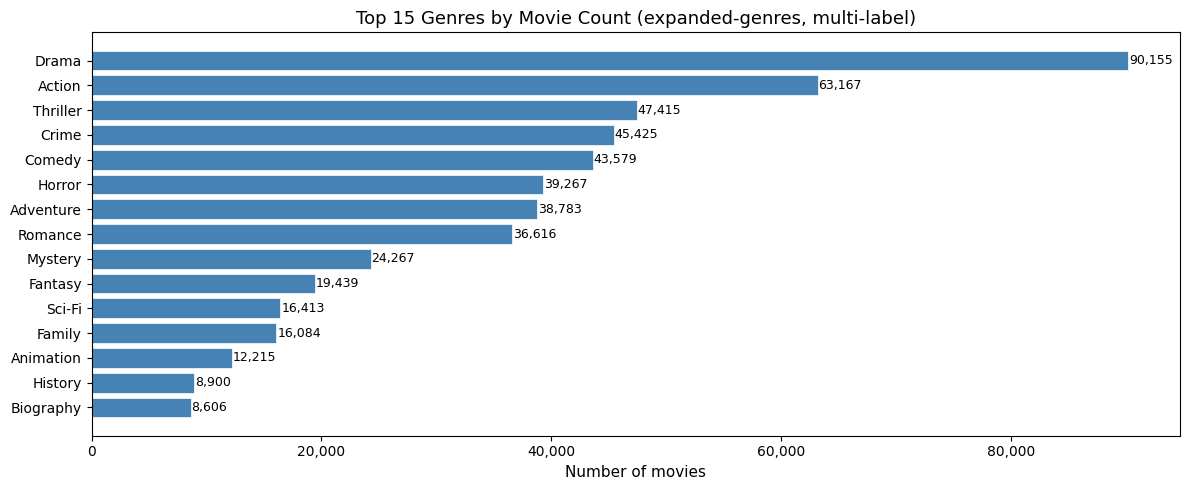

In [4]:
genre_counts = (
    df['expanded-genres']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of movies', fontsize=11)
ax.set_title('Top 15 Genres by Movie Count (expanded-genres, multi-label)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---

## 5. Rating Distribution Chart

Histogram of IMDb ratings across the preprocessed dataset.
Note that ~29% of movies have no rating (dropped as NaN before plotting).

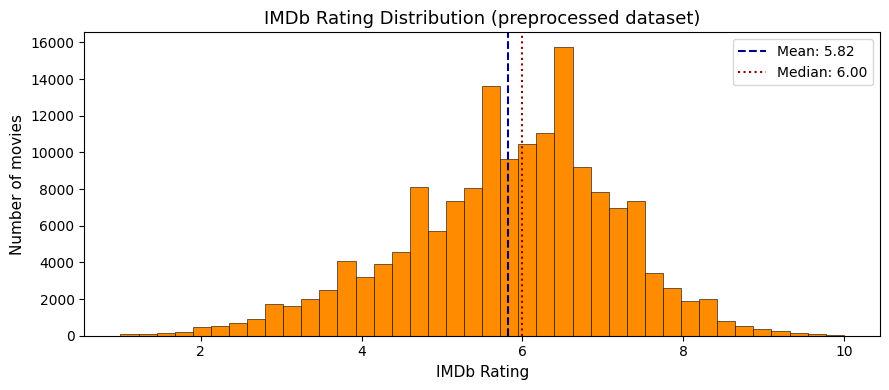

Rating stats (160,044 movies with rating):
count    160044.00
mean          5.82
std           1.32
min           1.00
25%           5.00
50%           6.00
75%           6.70
max          10.00
Name: rating, dtype: float64


In [5]:
ratings = pd.to_numeric(df['rating'], errors='coerce').dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ratings, bins=40, color='darkorange', edgecolor='black', linewidth=0.4)
ax.set_xlabel('IMDb Rating', fontsize=11)
ax.set_ylabel('Number of movies', fontsize=11)
ax.set_title('IMDb Rating Distribution (preprocessed dataset)', fontsize=13)
ax.axvline(ratings.mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f'Mean: {ratings.mean():.2f}')
ax.axvline(ratings.median(), color='darkred', linestyle=':', linewidth=1.5,
           label=f'Median: {ratings.median():.2f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Rating stats ({len(ratings):,} movies with rating):')
print(ratings.describe().round(2))

---

## 6. Sample Enriched Text

Show three example `enriched_text` values — this is the string the TF-IDF vectorizer
actually receives. The repetition of title tokens (×3) and genre tokens (×2) is the
field-weighting trick that boosts their importance without any custom TF-IDF extension.

In [6]:
print('Sample enriched_text entries (what the TF-IDF vectorizer sees):\n')
print('-' * 70)

sample = df[['movie title - year', 'genre', 'expanded-genres', 'enriched_text']].head(3)

for i, row in sample.iterrows():
    print(f"[{i}] Title   : {row['movie title - year']}")
    print(f"    Genre   : {row['expanded-genres']}")
    print(f"    Enriched: {row['enriched_text'][:220]}...")
    print('-' * 70)

Sample enriched_text entries (what the TF-IDF vectorizer sees):

----------------------------------------------------------------------
[0] Title   : Flaming Ears - 1992
    Genre   : Fantasy, Sci-Fi
    Enriched: flaming ear flaming ear flaming ear fantasy scifi fantasy scifi flaming ear pop scifi lesbian fantasy feature set year fictive burnedout city asche follows tangled life three woman volley nun spy...
----------------------------------------------------------------------
[1] Title   : Jeg elsker dig - 1957
    Genre   : Comedy, Drama, Romance
    Enriched: jeg elsker dig jeg elsker dig jeg elsker dig comedy drama romance comedy drama romance six people three couple meet random dance restaurant copenhagen nightlife marriage swindler former actress elderly supreme court atto...
----------------------------------------------------------------------
[2] Title   : Povjerenje - 2021
    Genre   : Thriller
    Enriched: povjerenje povjerenje povjerenje thriller thriller small unnamed 

---

## 7. Validation Testing

Load the `validation` split from the Hugging Face dataset, sample 5 titles that also
exist in the recommender index, and run `recommend_by_title()` on each.

In [7]:
val_df = load_dataset('jquigl/imdb-genres')['validation'].to_pandas()
print(f'Validation split size: {len(val_df):,} movies')

# Keep only titles that are actually in the recommender's index
indexed_titles = set(df['movie title - year'].dropna())
valid_titles = val_df[
    val_df['movie title - year'].isin(indexed_titles)
]['movie title - year'].dropna()

test_titles = valid_titles.sample(5, random_state=42).tolist()
print(f'Selected {len(test_titles)} test titles from validation split.\n')

print('=' * 62)
for title in test_titles:
    print(f"\nQuery: '{title}'")
    result = recommender.recommend_by_title(title, top_n=5)
    if isinstance(result, pd.DataFrame):
        print(result.to_string(index=False))
    else:
        print(result)
    print('-' * 62)

Validation split size: 29,809 movies
Selected 5 test titles from validation split.


Query: 'Pursuit to Algiers - 1945'
  Matched: 'Pursuit to Algiers - 1945'
                                  title  hybrid_score  tfidf_similarity     genre  rating
              Pursuit to Algiers - 1945        1.2144            1.0000   Romance     6.8
              Murder on Approval - 1955        0.4955            0.2944     Crime     5.6
Aska Susayanlar: Seks ve Cinayet - 1972        0.4870            0.2970     Crime     4.6
                       Mr. Angel - 1966        0.4840            0.2784 Adventure     NaN
                   Mystery House - 1938        0.4833            0.2833   Mystery     5.5
--------------------------------------------------------------

Query: 'Ilan-dili - 1926'
  Matched: 'Ilan-dili - 1926'
                        title  hybrid_score  tfidf_similarity     genre  rating
             Ilan-dili - 1926        1.1989            1.0000    Action     5.4
           Reformator

---

## 8. Precision@K Evaluation

For each of the 5 validation titles, count how many of the top-5 recommendations
share **at least one genre** with the query movie (genre-overlap hit).
Average across all queries to get **Genre-overlap Precision@5**.

This is a lightweight proxy metric — it measures whether the recommender stays
thematically on-target, without needing explicit user feedback.

In [8]:
def genre_overlap_precision_at_k(recommender, titles, k=5):
    """
    For each query title:
      1. Look up the query movie's expanded-genres.
      2. Fetch top-k recommendations via recommend_by_title().
      3. Count recommendations that share >= 1 genre with the query.
    Returns the mean precision across all valid queries.
    """
    scores = []

    for title in titles:
        match = recommender.df[
            recommender.df['movie title - year'].str.lower() == title.lower()
        ]
        if match.empty:
            print(f"  SKIP: '{title}' not found in recommender index.")
            continue

        # Build query genre set from expanded-genres (fall back to genre)
        genre_col = 'expanded-genres' if 'expanded-genres' in match.columns else 'genre'
        query_genres = {
            g.strip().lower()
            for g in str(match.iloc[0][genre_col]).split(',')
            if g.strip() and g.strip().lower() != 'nan'
        }

        recs = recommender.recommend_by_title(title, top_n=k)
        if isinstance(recs, str):   # error message returned
            continue

        hits = 0
        for _, row in recs.iterrows():
            rec_genres = {
                g.strip().lower()
                for g in str(row['genre']).split(',')
                if g.strip() and g.strip().lower() != 'nan'
            }
            if query_genres & rec_genres:   # at least one shared genre
                hits += 1

        precision = hits / k
        scores.append(precision)
        print(f"  '{title}'")
        print(f"    Query genres : {query_genres}")
        print(f"    Hits         : {hits}/{k}  →  precision = {precision:.2f}")

    mean_p = sum(scores) / len(scores) if scores else 0.0
    return mean_p


print('Genre-overlap Precision@5 evaluation')
print('=' * 62)
mean_precision = genre_overlap_precision_at_k(recommender, test_titles, k=5)
print(f'\nMean Genre-overlap Precision@5: {mean_precision:.2%}')

Genre-overlap Precision@5 evaluation
  Matched: 'Pursuit to Algiers - 1945'
  'Pursuit to Algiers - 1945'
    Query genres : {'adventure', 'crime', 'mystery'}
    Hits         : 4/5  →  precision = 0.80
  Matched: 'Ilan-dili - 1926'
  'Ilan-dili - 1926'
    Query genres : {'action', 'adventure', 'crime'}
    Hits         : 4/5  →  precision = 0.80
  Matched: 'Tarzan and the Mermaid - 1964'
  'Tarzan and the Mermaid - 1964'
    Query genres : {'action', 'adventure'}
    Hits         : 5/5  →  precision = 1.00
  Matched: 'Der Unendliche Weg - 1943'
  'Der Unendliche Weg - 1943'
    Query genres : {'history', 'drama', 'biography'}
    Hits         : 5/5  →  precision = 1.00
  Matched: 'Out of the Past - 1947'
  'Out of the Past - 1947'
    Query genres : {'drama', 'crime', 'film-noir'}
    Hits         : 5/5  →  precision = 1.00

Mean Genre-overlap Precision@5: 92.00%


---

## 9. Example Outputs — All Three Input Modes

Demonstrate each recommendation entry point:
- **recommend_by_title** — find movies similar to a known title
- **recommend_by_genre** — return top-rated movies within a genre
- **recommend_by_description** — match free-text vibe against the corpus

In [9]:
# ── Mode 1: recommend_by_title ─────────────────────────────────────────────
print('=' * 62)
print("Mode 1: recommend_by_title('The Dark Knight')")
print('=' * 62)
result_title = recommender.recommend_by_title('The Dark Knight')
print(result_title.to_string(index=False) if isinstance(result_title, pd.DataFrame) else result_title)

# ── Mode 2: recommend_by_genre ─────────────────────────────────────────────
print('\n' + '=' * 62)
print("Mode 2: recommend_by_genre('Crime')")
print('=' * 62)
result_genre = recommender.recommend_by_genre('Crime')
print(result_genre.to_string(index=False) if isinstance(result_genre, pd.DataFrame) else result_genre)

# ── Mode 3: recommend_by_description ──────────────────────────────────────
print('\n' + '=' * 62)
query_desc = 'a spy infiltrates enemy headquarters with betrayal'
print(f"Mode 3: recommend_by_description('{query_desc}')")
print('=' * 62)
result_desc = recommender.recommend_by_description(query_desc)
print(result_desc.to_string(index=False) if isinstance(result_desc, pd.DataFrame) else result_desc)

Mode 1: recommend_by_title('The Dark Knight')
  Matched: 'The Dark Knight - 2008'
                                title  hybrid_score  tfidf_similarity    genre  rating
               The Dark Knight - 2008        1.2389            1.0000   Action     9.0
                 Batman Begins - 2005        0.5679            0.3379   Action     8.2
Caped Crusader: The Dark Hours - 2014        0.5639            0.3472  Fantasy     7.0
              Batman: Crusader - 2014        0.5323            0.3290 Thriller     5.8
 Batman: The Dark Knight Beyond - nan        0.5155            0.4099   Action     NaN

Mode 2: recommend_by_genre('Crime')
                                                 title                    genre  rating
Angelito San Miguel at Ang Mga Batang City Jail - 1991     Action, Crime, Drama     9.8
                                           Hije - 2016 Crime, Mystery, Thriller     9.7
                                   Parvatinagar - 2022 Crime, Mystery, Thriller     9.7
       

---

## 10. Limitations and Future Work

### Current Limitations

**1. No semantic understanding (TF-IDF is purely lexical)**  
TF-IDF treats every token as an independent symbol. Synonyms such as *cop* and
*detective*, or *spacecraft* and *starship*, score zero overlap even though they
describe the same concept. A query for *"heist"* will miss movies described only
as *"robbery"*.

**2. Dataset gaps — famous movies are missing**  
The `jquigl/imdb-genres` dataset does not include many well-known titles
(e.g. *Titanic (1997)*, *The Shawshank Redemption*). Users querying for these
fall through to the fuzzy-match fallback or get no result at all.

**3. Cold-start problem for new movies**  
Any movie not present in the training corpus (and therefore absent from the
TF-IDF matrix) cannot be recommended. There is no mechanism to add a new title
without rebuilding the entire vectorizer.

**4. Noisy genre labels**  
The `expanded-genres` column is extracted automatically and contains inconsistencies
(e.g. *Scifi* vs *Sci-Fi* vs *Science Fiction*). This degrades the Jaccard genre
overlap bonus.

---

### Future Work

| Improvement | What it solves |
|---|---|
| **Sentence-BERT embeddings** | Dense semantic vectors capture synonyms and paraphrases — *"cop"* and *"detective"* become neighbours in embedding space |
| **Collaborative filtering layer** | Models user taste from viewing/rating history rather than content alone; eliminates cold-start for returning users |
| **Incremental index updates** | Add new movies to the FAISS/HNSW index without a full rebuild |
| **Genre normalisation** | Map variant spellings to a canonical set before computing Jaccard overlap |
| **Learnable reranking weights** | Replace the fixed `genre_weight=0.15` / `rating_weight=0.10` heuristics with weights tuned by cross-validation on explicit user feedback |